# Treinamento e validação de um  modelo  de  deep  learning utilizando LSTM para capturar padrões temporais nos dados de preços das ações

# IMPORTS

In [1]:
import logging
import math
import os
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Tuple

from datetime import datetime
import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset
import yfinance as yf

# REPRODUTIBILIDADE

In [2]:
@dataclass
class PipelineConfig:
    seed: int = 42
    symbol: str = "PETR4.SA"
    start_date: str = "2015-01-01"
    end_date: str = "2025-10-20"
    seq_len: int = 10
    batch_size: int = 32
    epochs: int = 200
    hidden_dim: int = 64
    num_layers: int = 2
    dropout: float = 0.2
    lr: float = 0.001
    train_ratio: float = 0.7
    val_ratio: float = 0.15
    model_dir: Path = Path("artifacts")
    model_name: str = "best_lstm_model.pth"
    scaler_name: str = "scaler.pkl"
    experiment_name: str = "lstm_stock_forecast"


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


config = PipelineConfig()
set_seed(config.seed)
config.model_dir.mkdir(parents=True, exist_ok=True)

# DEVICE

In [3]:
def setup_logging(base_dir: Path) -> Tuple[logging.Logger, Path]:
    # Create "logs" subfolder inside the given base directory
    log_dir = base_dir / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    # Generate a unique log filename with timestamp
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    log_path = log_dir / f"training_{timestamp}.log"

    # Configure logger
    logger = logging.getLogger("lstm_pipeline")
    logger.setLevel(logging.INFO)

    if not logger.handlers:
        formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')

        file_handler = logging.FileHandler(log_path, encoding="utf-8")
        file_handler.setFormatter(formatter)

        stream_handler = logging.StreamHandler()
        stream_handler.setFormatter(formatter)

        logger.addHandler(file_handler)
        logger.addHandler(stream_handler)

    return logger, log_path




logger, log_path = setup_logging(config.model_dir)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Usando device: {device}")
logger.info(f"Logging registrado em: {log_path}")

2025-10-29 08:14:17,997 | INFO | Usando device: cpu
2025-10-29 08:14:18,003 | INFO | Logging registrado em: artifacts\logs\training_2025-10-29_08-14-17.log


## COLETA DE DADOS

A Ação definida é a Petrobras com o ticker PETR4.SA.

In [4]:
def download_data() -> pd.DataFrame:
    logger.info(f"Baixando dados de {config.symbol} de {config.start_date} até {config.end_date}")
    df = yf.download(config.symbol, start=config.start_date, end=config.end_date)
    if df.empty:
        raise ValueError("Dataset vazio")
    logger.info(f"Dataset carregado com {df.shape[0]} linhas")
    return df


df_petrobras = download_data()
df_petrobras.head(1)

2025-10-29 08:14:18,017 | INFO | Baixando dados de PETR4.SA de 2015-01-01 até 2025-10-20
C:\Users\DELL\AppData\Local\Temp\ipykernel_8252\2642435497.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(config.symbol, start=config.start_date, end=config.end_date)
[*********************100%***********************]  1 of 1 completed
2025-10-29 08:14:18,909 | INFO | Dataset carregado com 2688 linhas


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2015-01-02,2.572509,2.745658,2.569761,2.745658,49559500


# PRÉ-PROCESSAMENTO DE DADOS

Vamos começar apenas utilizando os dados de fechamento do dia para prever séries temporais.

In [5]:
def prepare_close_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df_close = pd.DataFrame()
    df_close['x'] = df['Close']
    df_close['y'] = df['Close'].shift(-1)
    df_close = df_close.dropna().reset_index(drop=True)
    logger.info(f"Dataset de fechamento preparado com {df_close.shape[0]} linhas")
    return df_close


df_fechamento = prepare_close_dataset(df_petrobras)
df_fechamento.head()

2025-10-29 08:14:18,939 | INFO | Dataset de fechamento preparado com 2687 linhas


,x,y
0,2.572509,2.352637
1,2.352637,2.275681
2,2.275681,2.382869
3,2.382869,2.536780
4,2.536780,2.613735


# RESHAPE DOS VALORES DE ENTRADA

In [6]:
values = df_fechamento['x'].values.reshape(-1, 1)
values

array([[ 2.57250881],
       [ 2.35263681],
       [ 2.27568126],
       ...,
       [30.02000046],
       [29.75      ],
       [29.45000076]])

# Escala para [0,1] (importante para LSTM)

In [7]:
# Caminho onde o scaler será salvo
scaler_path = Path(config.model_dir) / "scaler.joblib"

# Escalonamento
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)
logger.info("Escalonamento concluído")

# Salva o scaler
joblib.dump(scaler, scaler_path)
logger.info(f"Scaler salvo em: {scaler_path}")

2025-10-29 08:14:18,972 | INFO | Escalonamento concluído
2025-10-29 08:14:18,994 | INFO | Scaler salvo em: artifacts\scaler.joblib


# SEQUENCIA DE DIAS: quantos dias anteriores usar para predizer o próximo dia

In [8]:
def create_sequences(data: np.ndarray, seq_len: int) -> Tuple[np.ndarray, np.ndarray]:
    xs = []
    ys = []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len])
    return np.array(xs), np.array(ys)

X, y = create_sequences(values_scaled, config.seq_len)
logger.info(f"Sequências de {config.seq_len} geradas: X={X.shape}, y={y.shape}")
print(X.shape)
print(y.shape)

2025-10-29 08:14:19,011 | INFO | Sequências de 10 geradas: X=(2677, 10, 1), y=(2677, 1)


(2677, 10, 1)
(2677, 1)


# SEPARA DADOS EM treino, teste e validação

In [9]:
n = len(X)
n_train = int(n * config.train_ratio)
n_val = int(n * config.val_ratio)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]
logger.info(f"Divisões: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

print("Divisões:", X_train.shape, X_val.shape, X_test.shape)


2025-10-29 08:14:19,027 | INFO | Divisões: train=(1873, 10, 1), val=(401, 10, 1), test=(403, 10, 1)


Divisões: (1873, 10, 1) (401, 10, 1) (403, 10, 1)


# Dataset e Dataloader - PYTORCH

In [10]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # X shape (N, seq_len, 1)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # retorna (seq, target)
        return self.X[idx], self.y[idx]


train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=config.batch_size, shuffle=False)

# MODELO LSTM

In [11]:
class LSTMForecast(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=50, num_layers=2, output_dim=1, dropout=0.2):
        super(LSTMForecast, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        # camada fully-connected para mapear hidden -> saída
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        batch_size = x.size(0)
        # inicializar hidden e cell states com zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)

        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_len, hidden_dim)
        # Pegar apenas a última saída do sequence (many-to-one)
        out = out[:, -1, :]  # (batch, hidden_dim)
        out = self.fc(out)   # (batch, output_dim)
        return out

# Instanciar modelo
model = LSTMForecast(input_dim=1, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.2).to(device)
logger.info(f"Model LSTM:\n{model}")

2025-10-29 08:14:19,060 | INFO | Model LSTM:
LSTMForecast(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# Critério e otimizador

In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# O ReduceLROnPlateau ajusta automaticamente a taxa de aprendizado (learning rate) quando o modelo entra em um platô
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
logger.info(f"criterion: {criterion}")
logger.info(f"optimizer: {optimizer}")
logger.info(f"scheduler: {scheduler}")

2025-10-29 08:14:20,640 | INFO | criterion: MSELoss()
2025-10-29 08:14:20,645 | INFO | optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
2025-10-29 08:14:20,645 | INFO | scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x0000027326AE44D0>


# TREINAR MODELO

In [ ]:
best_val_loss = float('inf')
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, config.epochs+1):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)  # (batch, seq_len, 1)
        y_batch = y_batch.to(device)  # (batch, 1)

        optimizer.zero_grad()
        y_pred = model(X_batch).squeeze()  # (batch,)
        loss = criterion(y_pred, y_batch.squeeze())
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # validação
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch.squeeze())
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses) if len(val_losses) > 0 else None
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # scheduler step
    if val_loss is not None:
        scheduler.step(val_loss)

    # salvar melhor modelo
    if val_loss is not None and val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), Path(config.model_dir) / "best_model.pth")

    if epoch % 10 == 0 or epoch == 1:
        logger.info(f"Epoch {epoch}/{config.epochs}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}")

logger.info(f"Treino finalizado. Melhor val_loss: {best_val_loss}")

2025-10-29 08:14:21,009 | INFO | Epoch 1/200  train_loss=0.011505  val_loss=0.195828
2025-10-29 08:14:23,555 | INFO | Epoch 10/200  train_loss=0.000170  val_loss=0.003146
2025-10-29 08:14:26,545 | INFO | Epoch 20/200  train_loss=0.000143  val_loss=0.002015
2025-10-29 08:14:29,294 | INFO | Epoch 30/200  train_loss=0.000130  val_loss=0.002220
2025-10-29 08:14:32,209 | INFO | Epoch 40/200  train_loss=0.000126  val_loss=0.001968
2025-10-29 08:14:34,895 | INFO | Epoch 50/200  train_loss=0.000124  val_loss=0.001999
2025-10-29 08:14:37,773 | INFO | Epoch 60/200  train_loss=0.000135  val_loss=0.002006
2025-10-29 08:14:40,473 | INFO | Epoch 70/200  train_loss=0.000128  val_loss=0.001995
2025-10-29 08:14:43,175 | INFO | Epoch 80/200  train_loss=0.000127  val_loss=0.001997
2025-10-29 08:14:46,331 | INFO | Epoch 90/200  train_loss=0.000124  val_loss=0.001992
2025-10-29 08:14:49,525 | INFO | Epoch 100/200  train_loss=0.000127  val_loss=0.001990
2025-10-29 08:14:52,722 | INFO | Epoch 110/200  train_

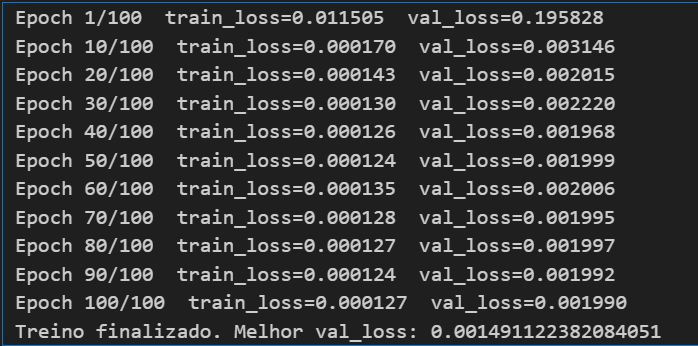

Durante o treinamento, o modelo LSTM apresentou uma rápida redução das perdas de treino e validação nas primeiras épocas, convergindo de forma estável após cerca de 20 iterações.
A menor perda de validação obtida foi de 0.00149, demonstrando boa capacidade de generalização.
Observou-se também que as perdas de treino e validação se mantiveram próximas, o que indica ausência de overfitting.

# AVALIAÇÃO DO MODELO

In [14]:
# Carrega melhor modelo
model.load_state_dict(torch.load(Path(config.model_dir) / "best_model.pth"))
model.eval()

preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        y_pred = model(X_batch).squeeze().cpu().numpy()
        preds.append(y_pred)
        targets.append(y_batch.squeeze().cpu().numpy())

preds = np.concatenate(preds, axis=0)
targets = np.concatenate(targets, axis=0)

# Inverte escala (MinMaxScaler)
preds_inv = scaler.inverse_transform(preds.reshape(-1,1)).reshape(-1)
targets_inv = scaler.inverse_transform(targets.reshape(-1,1)).reshape(-1)

rmse = math.sqrt(mean_squared_error(targets_inv, preds_inv))
logger.info(f"Test RMSE = {rmse:.6f}")

2025-10-29 08:15:22,601 | INFO | Test RMSE = 1.202218


In [15]:
df_fechamento.tail()

,x,y
2682,29.940001,30.230000
2683,30.230000,30.020000
2684,30.020000,29.750000
2685,29.750000,29.450001
2686,29.450001,29.730000


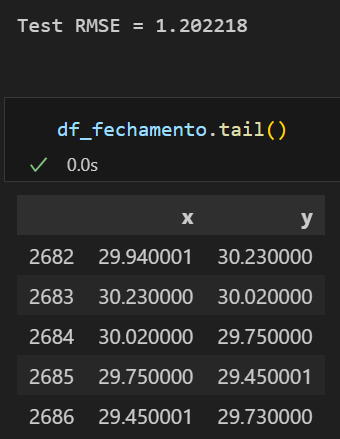

In [16]:
1.2/30

0.04

Os valores da Petrobras ficam em torno de 30 reais portanto o desvio de 1,20 é considerado bom, ficando em torno de 1.2/30 = 4%.

# PLOT REAL X PREVISTO

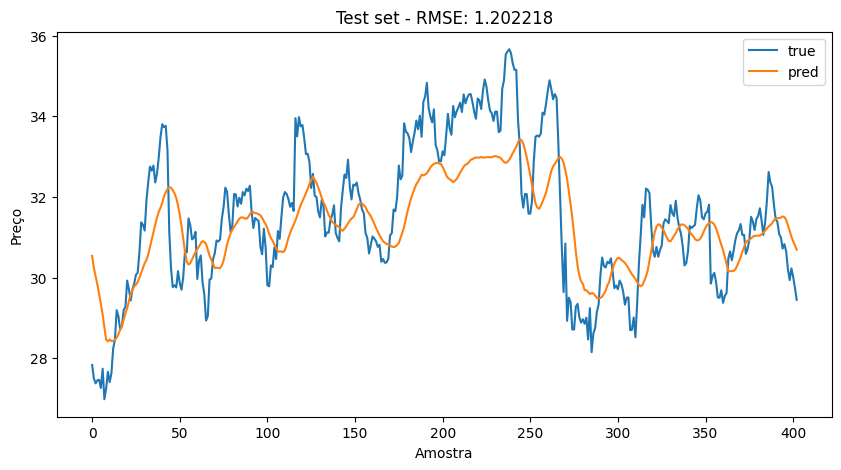

In [17]:
plt.figure(figsize=(10,5))
plt.plot(targets_inv, label="true")
plt.plot(preds_inv, label="pred")
plt.legend()
plt.title(f"Test set - RMSE: {rmse:.6f}")
plt.xlabel("Amostra")
plt.ylabel("Preço")
plt.show()

# PREVISÃO DO ULTIMO DIA (AINDA NAO EXISTE NO DF)

In [ ]:
def predict_next(model, last_seq, scaler):
    """
    last_seq: array shape (seq_len, 1) com os valores originais (não escalados) OU escalados.
    Se não estiver escalado, escalamos aqui.
    Retorna valor previso na escala original.
    """
    model.eval()
    arr = np.array(last_seq).reshape(-1,1)
    # detectar se já está escalado (valor entre 0 e 1)
    if arr.max() > 1.0 or arr.min() < 0.0:
        arr_scaled = scaler.transform(arr)
    else:
        arr_scaled = arr

    input_seq = torch.tensor(arr_scaled.reshape(1, arr_scaled.shape[0], 1), dtype=torch.float32).to(device)
    with torch.no_grad():
        y_pred = model(input_seq).cpu().numpy().reshape(-1,1)
    y_pred_inv = scaler.inverse_transform(y_pred)
    return y_pred_inv.ravel()[0]

last_seq_real = values[-config.seq_len:] 
next_pred = predict_next(model, last_seq_real, scaler)
logger.info(f"Próximo dia (predição) = {next_pred}")

--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\ipyk